**Nikhil Sunder**  
ICSRI Research Fellow, University of Miami | Open-Source Developer  
Herbert Business School, University of Miami  
B.S.B.A. Quantitative Economics & Finance; Minor in Mathematics  

**Correspondence:** nss106@miami.edu  
**Research profiles:** [GitHub](https://github.com/nikhilxsunder) · [ORCID](https://orcid.org/0009-0007-3323-1760) · [LinkedIn](https://www.linkedin.com/in/nikhil-sunder/) · [Zenodo](https://zenodo.org/search?q=metadata.creators.person_or_org.name:%22Sunder,+Nikhil%22)  
**Software:** [PyPI](https://pypi.org/user/nikhil.sunder/) · [Anaconda](https://anaconda.org/nikhil.sunder/)

# 2. Linear economy: rolling and expanding re-estimation

Two robustness variants of the baseline: the unrestricted recursive SVAR(2) re-estimated every quarter
on a rolling window and on an expanding window, followed by a formal out-of-sample comparison with the
fixed-coefficient economy of notebook `01_linear_svar`.

**Inputs:** `artifacts/data/`, `artifacts/linear/one_step_fixed.csv`.
**Outputs:** `artifacts/linear/one_step_rolling.csv`, `artifacts/linear/one_step_expanding.csv`.

In [17]:
import numpy as np
import pandas as pd
from cultivars.forecast import (
    Backtest,
    ForecastComparison,
    mincer_zarnowitz,
    model_confidence_set,
)
from cultivars.multivariate import VAR

import autofed as af
from autofed import linear as lin
from autofed import plots

nb = af.NotebookSession(
    "02_linear_rolling_expanding",
    number=2,
    title="Linear economy: rolling and expanding re-estimation",
)
panel = af.load_macro_panel(nb.artifacts("data"))
cfg = panel.config
NAMES = list(af.NAMES)  # recursive ordering: y -> pi -> i
df_train, df_all = panel.train, panel.full
print(
    f"Data vintage {panel.retrieved} | training {df_train.index[0]}-{df_train.index[-1]} | "
    f"full {df_all.index[0]}-{df_all.index[-1]}"
)

fixed = af.load_frame(
    nb.artifacts("linear") / "one_step_fixed.csv", producer="notebook 01_linear_svar"
)
oos_fixed = fixed.loc[cfg.oos_start :]


def squared(frame: pd.DataFrame, column: str) -> pd.Series:
    return (frame[column] - frame[f"{column}_hat"]) ** 2


def metrics_table(frames: dict[str, pd.DataFrame]) -> pd.DataFrame:
    table = pd.DataFrame({label: lin.error_metrics(frame) for label, frame in frames.items()}).T
    table["n"] = table["n"].astype(int)
    return table

Data vintage 2026-10-07 | training 1987Q3-2007Q2 | full 1987Q3-2026Q2


# Alternative Specification: Rolling-Window SVAR(2) (Unrestricted)

This section estimates a robustness variant of the baseline linear environment. Instead of restricting
the SVAR(2) by dropping statistically weak second-lag terms, we estimate an **unrestricted SVAR(2)** on a
**rolling window**. The rolling-window design allows the effective law of motion to vary over time by
re-estimating parameters on a moving subsample, which is a standard device when forecast performance
may be affected by **structural change** or **parameter instability** (Clements & Hendry, 1998; Stock &
Watson, 2007). Identification follows the same recursive ordering used in the baseline SVAR (Sims, 1980;
Lütkepohl, 2005), declared through `RecursiveSVAR` on every window.

## Data (unchanged)

The observable definitions and transformations are unchanged relative to the baseline specification.
The loops below work from the same saved panel (1987Q3 to the latest observation); no series is
re-fetched.

## Rolling estimation design

### Window length and evaluation period

Let $W$ denote the rolling window length in quarters. In this alternative specification we use
$W = 40$ (ten years) **throughout**.

For each evaluation quarter $t$, the SVAR(2) is estimated on the trailing subsample $[t-W,\;t-1]$, and
one-step-ahead fitted values $(\hat y_t,\hat\pi_t)$ are computed using realized regressors. This produces
a time series of locally re-estimated parameters $\{\hat\theta_t\}$ and fitted values that can adapt to
changing reduced-form relationships.

**On the window length.** An earlier version of this exercise used $W = 4$. Each equation has seven
regressors and a two-lag VAR loses two rows to lags, so a four-quarter window leaves two observations for
seven coefficients: the OLS problem is rank-deficient and any fitted values it produces are artefacts of
the pseudo-inverse. `cultivars` refuses that specification (a VAR(2) in three variables needs at least
ten rows to be estimable and eleven for a non-singular residual covariance). $W = 40$ gives 38 effective
observations per window, enough for the coefficients to be determined by the data while still allowing
the law of motion to drift across a decade; the window-length sensitivity table at the end of this
section shows how estimation noise grows as $W$ is shortened.

### Rolling sample and no-look-ahead rule

For each quarter $t$, the rolling SVAR(2) is estimated using only the trailing subsample $[t-W,\;t-1]$
with $W=40$. This enforces a strict **no-look-ahead** rule: parameters used to form $(\hat y_t,\hat\pi_t)$
depend only on information available prior to quarter $t$.

Implementation-wise, the rolling code requires a single quarterly panel containing $\pi_t$, $y_t$, and
$i_t$ over the span where rolling fitted values are desired. The notebook uses a quarterly `PeriodIndex`
so that lag operations ($t-1$, $t-2$) are well-defined; within the loop the panel is addressed by
integer position for speed.

### Estimation details (unrestricted, equation-by-equation)

Within each rolling window, both equations are estimated by least squares **without** post-estimation
lag selection. That is, all first- and second-lag regressors are retained in every window:

- Output-gap equation regressors: $(y_{t-1}, y_{t-2}, \pi_{t-1}, \pi_{t-2}, i_{t-1}, i_{t-2})$
- Inflation equation regressors: $(y_t, y_{t-1}, y_{t-2}, \pi_{t-1}, \pi_{t-2}, i_{t-1}, i_{t-2})$

This differs from the baseline specification, where the second-lag terms may be dropped based on
full-sample significance. Here, coefficient variation is driven by **window re-estimation** rather than
explicit restriction.

## Unrestricted recursive SVAR(2)

Let the state vector include output gap $y_t$, inflation $\pi_t$, and the policy rate $i_t$. The rolling
specification retains the same recursive ordering as the baseline, while **retaining all first- and
second-lag regressors** (no lag dropping).

1. **Output-gap equation (reduced form)**
$$
y_t = C^y + a^y_{y,1}y_{t-1} + a^y_{y,2}y_{t-2}
      + a^y_{\pi,1}\pi_{t-1} + a^y_{\pi,2}\pi_{t-2}
      + a^y_{i,1}i_{t-1} + a^y_{i,2}i_{t-2} + \varepsilon^y_t.
$$

2. **Inflation equation (recursive ordering)**
$$
\pi_t = C^\pi + a^\pi_{y,0}y_{t} + a^\pi_{y,1}y_{t-1} + a^\pi_{y,2}y_{t-2}
        + a^\pi_{\pi,1}\pi_{t-1} + a^\pi_{\pi,2}\pi_{t-2}
        + a^\pi_{i,1}i_{t-1} + a^\pi_{i,2}i_{t-2} + \varepsilon^\pi_t.
$$

Each equation is estimated by least squares within the rolling window. The recursive contemporaneous
term $y_t$ in the inflation equation corresponds to a standard triangular (Cholesky-style) ordering used in
VAR/SVAR applications (Sims, 1980; Lütkepohl, 2005).

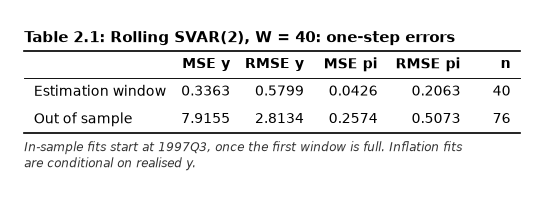

In [18]:
W = 40  # rolling window, quarters
roll_all = df_all.join(lin.rolling_one_step(df_all, W, cfg.train_start))
roll_is = roll_all.loc[: cfg.train_end].dropna()
roll_oos = roll_all.loc[cfg.oos_start :].dropna()
af.save_frame(roll_all, nb.artifacts("linear") / "one_step_rolling.csv")

nb.table(
    metrics_table({"Estimation window": roll_is, "Out of sample": roll_oos}),
    "rolling_error_metrics",
    f"Rolling SVAR(2), W = {W}: one-step errors",
    float_format="{:.4f}",
    note=(
        f"In-sample fits start at {roll_is.index[0]}, once the first window is full. "
        "Inflation fits are conditional on realised y."
    ),
)

## Rolling fit diagnostics

With rolling estimation using $W=40$, the core diagnostics are:

- **In-sample (1987Q3–2007Q2):** squared errors from the rolling fitted values (the two figures that follow).
  Because the first window must be filled before any fitted value exists, in-sample rolling fits start
  ten years into the training window (1997Q3).
- **Out-of-sample (2007Q3 onward):** actual vs. rolling fitted values and squared errors computed from
  the rolling loop.

Squared errors are defined as:
$$
SE^y_t = (y_t - \hat y_t)^2,\qquad SE^\pi_t = (\pi_t - \hat\pi_t)^2.
$$

Summaries (mean squared error and its root) are reported over both evaluation subsamples.

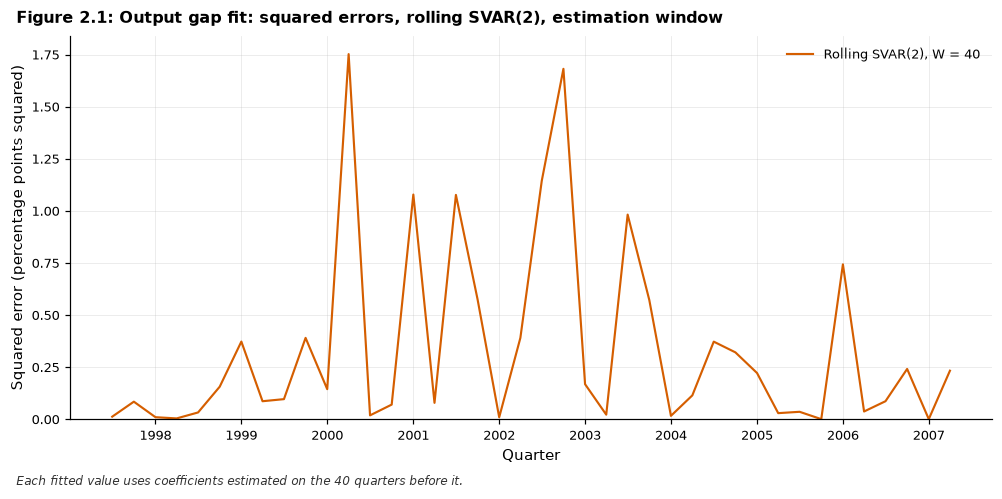

In [19]:
fig = plots.squared_errors({f"Rolling SVAR(2), W = {W}": squared(roll_is, "y")})
nb.figure(
    fig,
    "rolling_se_output_gap",
    "Output gap fit: squared errors, rolling SVAR(2), estimation window",
    note="Each fitted value uses coefficients estimated on the 40 quarters before it.",
)

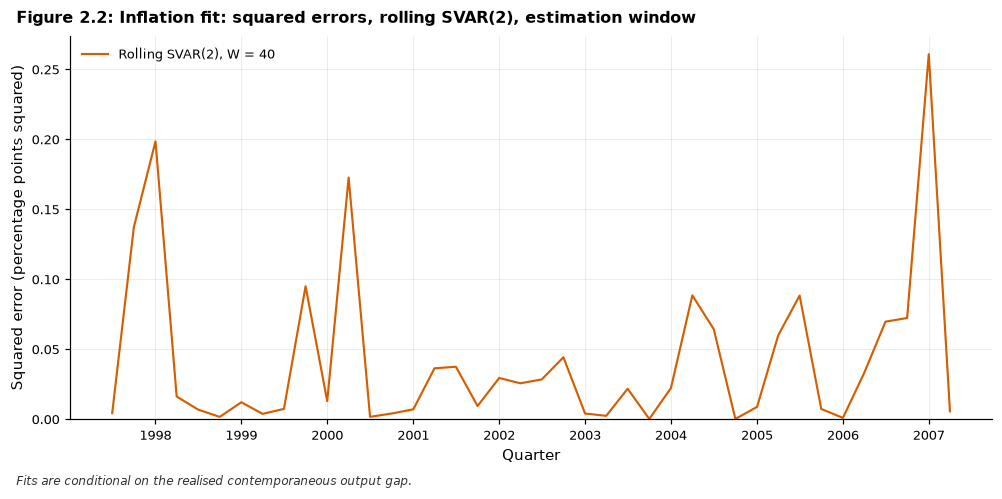

In [20]:
fig = plots.squared_errors({f"Rolling SVAR(2), W = {W}": squared(roll_is, "pi")})
nb.figure(
    fig,
    "rolling_se_inflation",
    "Inflation fit: squared errors, rolling SVAR(2), estimation window",
    note="Fits are conditional on the realised contemporaneous output gap.",
)

**Interpretation note (rolling window):** With $W=40$, each window contains 38 effective observations for
seven coefficients per equation, so the local estimates are determined by the data but remain
considerably noisier than the full-sample baseline. These plots are therefore best read as a diagnostic
for **time variation / instability** under re-estimation rather than as a precision-optimized fit
measure.

## Forecast construction and interpretation

### One-step-ahead mapping
For each quarter $t$, we compute one-step fitted values using the coefficients estimated on
$[t-W,\,t-1]$. Unless explicitly stated otherwise, the regressors are formed from **realized** lagged
values $(y_{t-1}, y_{t-2}, \pi_{t-1}, \pi_{t-2}, i_{t-1}, i_{t-2})$. This isolates the quality of the
local linear mapping from the accumulation of multi-step forecast error.

### Conditional vs. fully model-based inflation prediction
Because the recursive ordering includes contemporaneous $y_t$ in the inflation equation, $\hat \pi_t$ can
be computed either:
- **Conditionally**, using the realized $y_t$ (interpretable as a partial-equilibrium or conditional
  forecast), or
- **Fully model-based**, substituting $y_t$ with $\hat y_t$ from the rolling output-gap equation.

The notebook reports the conditional version by default to separate coefficient drift from feedback
error introduced by recursive substitution.

### Forecast inputs used in the rolling loop

The rolling loop produces one-step-ahead fitted values using **realized lagged inputs** from the data:

- $\hat y_t$ uses $(y_{t-1}, y_{t-2}, \pi_{t-1}, \pi_{t-2}, i_{t-1}, i_{t-2})$.
- $\hat\pi_t$ is computed **conditionally** using realized contemporaneous $y_t$ (i.e., the recursive
  term is treated as observed).

The conditional inflation fit isolates variation coming from rolling coefficients and lag dynamics, and
avoids additional error propagation that would occur if $y_t$ were replaced by $\hat y_t$ inside the
inflation equation.

## Out-of-sample evaluation (Rolling SVAR(2), unrestricted, $W=40$)

We evaluate the rolling-window SVAR(2) on the post-training period starting in **2007Q3**. For each
quarter $t$, model parameters are re-estimated using only the trailing subsample $[t-W,\;t-1]$ with
$W=40$, and one-step-ahead fitted values $(\hat y_t,\hat\pi_t)$ are constructed using **realized** lagged
inputs. With a ten-year window the first out-of-sample quarter already has a full estimation window
behind it, so fitted values exist for every out-of-sample observation.

### Out-of-sample tracking: output gap ($y_t$)

The figure compares the realized output gap $y_t$ to the rolling SVAR fitted value $\hat y_t$ for the
out-of-sample period (2007Q3 onward). This is a descriptive assessment of how the locally re-estimated
linear mapping tracks realized dynamics under potential structural change.

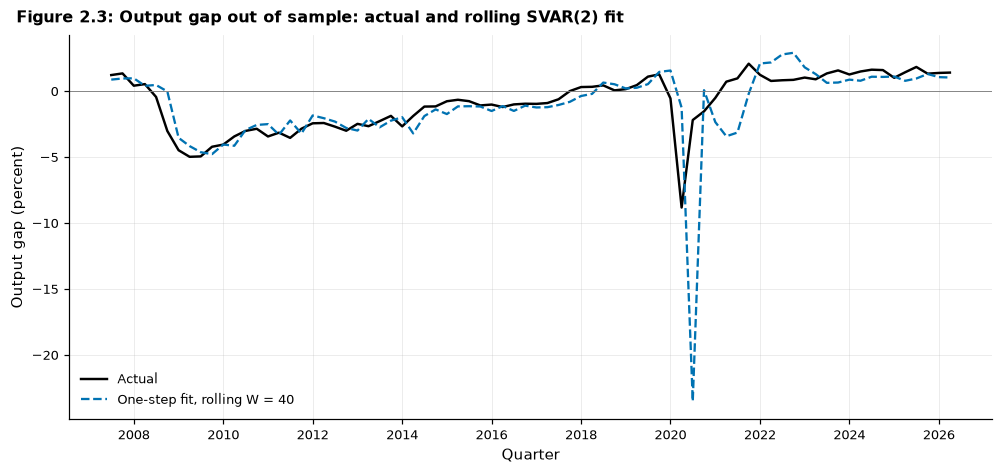

In [21]:
fig = plots.actual_vs_fit(roll_oos, "y", {f"One-step fit, rolling W = {W}": "y_hat"})
nb.figure(
    fig, "rolling_oos_output_gap", "Output gap out of sample: actual and rolling SVAR(2) fit"
)

### Out-of-sample tracking: inflation ($\pi_t$, conditional fit)

Because the recursive ordering includes contemporaneous $y_t$ in the inflation equation, the rolling
inflation fitted value $\hat\pi_t$ is computed **conditionally** using realized $y_t$ (rather than
substituting $\hat y_t$). This choice isolates coefficient drift and lag dynamics from additional error
propagation due to recursive substitution.

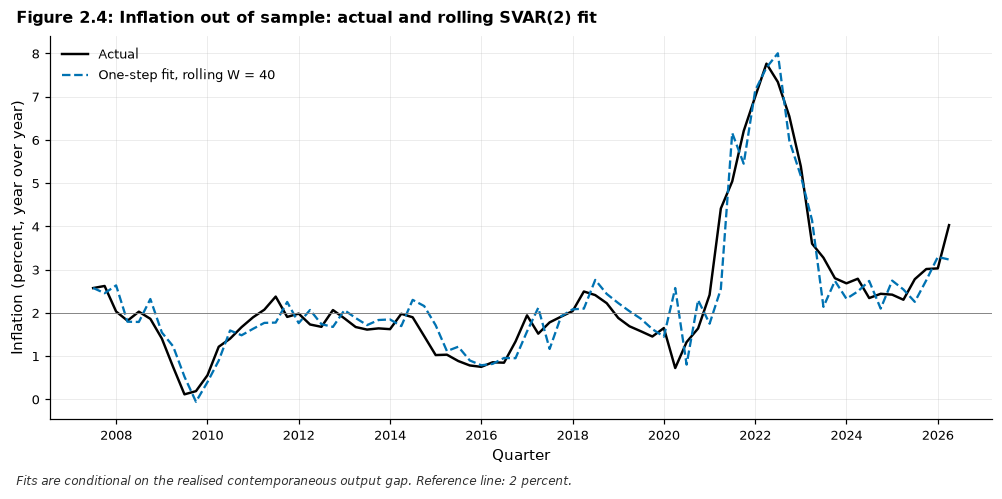

In [22]:
fig = plots.actual_vs_fit(roll_oos, "pi", {f"One-step fit, rolling W = {W}": "pi_hat"})
nb.figure(
    fig,
    "rolling_oos_inflation",
    "Inflation out of sample: actual and rolling SVAR(2) fit",
    note=(
        "Fits are conditional on the realised contemporaneous output gap. Reference line: 2"
        " percent."
    ),
)

### Out-of-sample error metrics

For completeness, we summarize out-of-sample performance using mean squared error (MSE) and root mean
squared error (RMSE) over the post-2007Q3 subsample where rolling fitted values are available:
$$
\text{MSE}^m = \frac{1}{T}\sum_t (x_t^m-\hat x_t^m)^2,\qquad
\text{RMSE}^m = \sqrt{\text{MSE}^m},\quad m\in\{y,\pi\}.
$$
These metrics are reported separately for the output gap and inflation series.

### Window-length sensitivity

The rolling design trades adaptivity against estimation noise. The table reports out-of-sample RMSE for
several window lengths; the baseline $W = 40$ is included for reference. Shorter windows track the
post-2007 regimes more closely only if the gain in adaptivity outweighs the loss of precision, which the
numbers below make explicit.

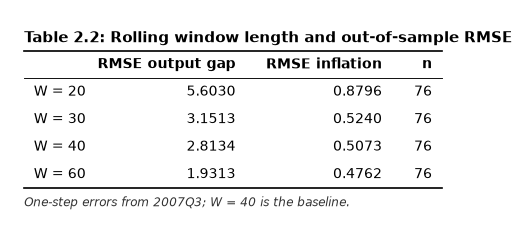

In [23]:
WINDOWS = (20, 30, 40, 60)
sensitivity = {}
for w in WINDOWS:
    frame = (
        df_all.join(lin.rolling_one_step(df_all, w, cfg.oos_start))
        .loc[cfg.oos_start :]
        .dropna()
    )
    sensitivity[f"W = {w}"] = {
        "RMSE output gap": lin.error_metrics(frame)["RMSE y"],
        "RMSE inflation": lin.error_metrics(frame)["RMSE pi"],
        "n": len(frame),
    }
sensitivity = pd.DataFrame(sensitivity).T
sensitivity["n"] = sensitivity["n"].astype(int)
nb.table(
    sensitivity,
    "rolling_window_sensitivity",
    "Rolling window length and out-of-sample RMSE",
    float_format="{:.4f}",
    note=f"One-step errors from {cfg.oos_start}; W = 40 is the baseline.",
)

## What this robustness check evaluates

Relative to a fixed-parameter SVAR estimated on a long pre-crisis window, rolling estimation tests whether
allowing parameters to adapt improves descriptive out-of-sample tracking when the economy undergoes
regime shifts (e.g., the Global Financial Crisis and the effective lower bound period). Evidence that the
rolling SVAR improves fit is consistent with time variation in reduced-form relationships, a common
explanation for macro forecast instability (Stock & Watson, 2007; Clements & Hendry, 1998).

### Interpretation caveats

Rolling estimation trades off flexibility and precision: using shorter windows can adapt to structural
change, but increases sampling variation in the coefficient estimates. Accordingly, improvements in
rolling tracking should be interpreted as evidence consistent with **time variation in reduced-form
relationships**, not as structural identification or policy-invariance.

# Modified Alternative Specification: Expanding-Window SVAR(2) (Unrestricted)

This section estimates an additional robustness variant of the linear environment using an
expanding-window recursive SVAR(2) (Sims, 1980; Lütkepohl, 2005). Relative to the rolling-window
specification, the expanding-window design re-estimates the same unrestricted recursive SVAR(2) each
quarter (Hamilton, 1994) using all data available from the initial estimation start through quarter
$t-1$. This preserves the no-look-ahead rule while allowing the effective estimation sample to grow over
time.

The expanding-window design is useful when coefficient instability may still matter, but the rolling
window is judged too short and therefore too noisy. In this setup, parameters are allowed to update as new
data arrive, while estimation precision improves over time because each successive regression is fit on a
larger sample.

## Expanding-window estimation design

Let $t_0$ denote the first quarter in the available sample and let $t$ denote the forecast quarter. For
each quarter $t$, the recursive SVAR(2) is estimated on the full historical subsample

$$
[t_0,\, t-1].
$$

This corresponds to recursive (expanding-window) estimation in the sense of Hamilton (1994), where the
information set grows monotonically over time.

Unlike the rolling-window specification, no observations are discarded once they enter the estimation
sample, in contrast to rolling-window estimation, which uses a fixed-length subsample (Giacomini & White,
2006). Thus, the coefficient estimates evolve through recursive re-estimation on an expanding information
set rather than through repeated estimation on a fixed-length moving window.

As in the rolling specification, the model remains unrestricted: all first- and second-lag regressors are
retained in both equations, and inflation is computed conditionally using realized contemporaneous $y_t$
under the recursive ordering. The first estimation uses twelve quarters (1987Q3–1990Q2), the smallest
sample on which the three-variable VAR(2) is comfortably estimable; earlier fitted values would be
dominated by estimation noise.

## Recursive unrestricted SVAR(2)

The expanding-window specification retains the same recursive reduced-form system used in the rolling
specification:

1. Output-gap equation
$$
y_t = C^y + a^y_{y,1} y_{t-1} + a^y_{y,2} y_{t-2}
      + a^y_{\pi,1} \pi_{t-1} + a^y_{\pi,2} \pi_{t-2}
      + a^y_{i,1} i_{t-1} + a^y_{i,2} i_{t-2} + \varepsilon^y_t.
$$

2. Inflation equation
$$
\pi_t = C^\pi + a^\pi_{y,0} y_t + a^\pi_{y,1} y_{t-1} + a^\pi_{y,2} y_{t-2}
        + a^\pi_{\pi,1} \pi_{t-1} + a^\pi_{\pi,2} \pi_{t-2}
        + a^\pi_{i,1} i_{t-1} + a^\pi_{i,2} i_{t-2} + \varepsilon^\pi_t.
$$

This recursive identification scheme follows the standard triangular (Cholesky-style) ordering commonly
used in SVAR models (Sims, 1980; Lütkepohl, 2005).

The only change relative to the rolling-window specification is the estimation window. Forecast
construction, recursive ordering, and regressor timing remain unchanged.

## Forecast construction and interpretation

For each quarter $t$, one-step-ahead fitted values are computed using coefficients estimated on the
expanding sample ending at $t-1$. This corresponds to recursive real-time forecasting using expanding
information sets (Hamilton, 1994). As in the earlier sections, realized lagged values are used to form the
regressors. Thus:

- $\hat y_t$ uses realized $(y_{t-1}, y_{t-2}, \pi_{t-1}, \pi_{t-2}, i_{t-1}, i_{t-2})$
- $\hat \pi_t$ is computed conditionally using realized contemporaneous $y_t$

This keeps the expanding-window results directly comparable to both the fixed-parameter baseline and the
rolling-window SVAR, while avoiding additional multi-step feedback error.

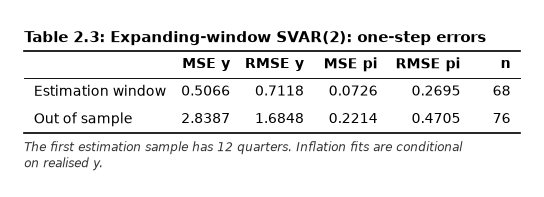

In [24]:
MIN_EXPANDING = 12  # first estimation sample, quarters
exp_all = df_all.join(lin.expanding_one_step(df_all, cfg.train_start, minimum=MIN_EXPANDING))
exp_is = exp_all.loc[: cfg.train_end].dropna()
exp_oos = exp_all.loc[cfg.oos_start :].dropna()
af.save_frame(exp_all, nb.artifacts("linear") / "one_step_expanding.csv")

nb.table(
    metrics_table({"Estimation window": exp_is, "Out of sample": exp_oos}),
    "expanding_error_metrics",
    "Expanding-window SVAR(2): one-step errors",
    float_format="{:.4f}",
    note=(
        f"The first estimation sample has {MIN_EXPANDING} quarters. Inflation fits are"
        " conditional on realised y."
    ),
)

## In-sample fit diagnostics

To compare the expanding-window SVAR(2) to the baseline and rolling alternatives, we compute one-step-ahead
fitted values and squared errors over the training period. Because the estimation sample expands
recursively, the earliest in-sample fitted values are based on smaller subsamples, while later fitted
values reflect increasingly stable parameter estimates.

As in the previous sections, the plotted squared errors should be read as descriptive diagnostics of fit
rather than as formal forecast-evaluation statistics in the sense of Giacomini & White (2006); the formal
tests follow in the next section.

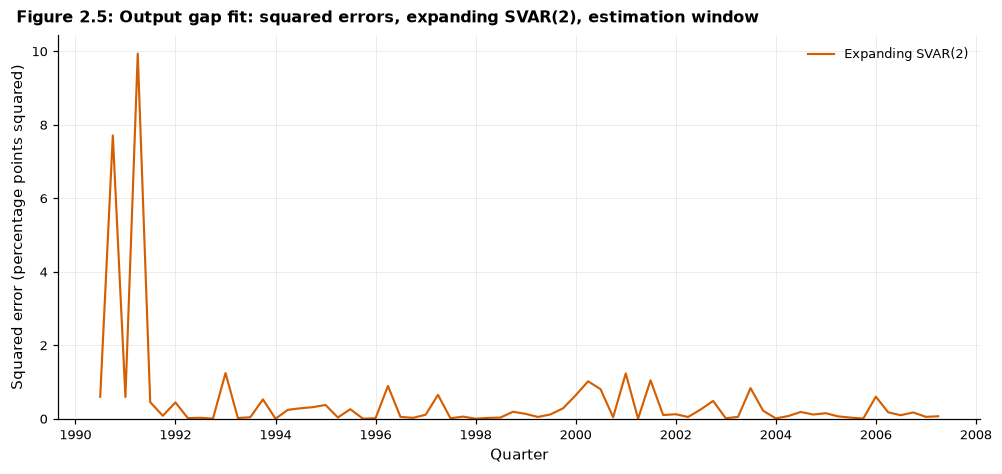

In [25]:
fig = plots.squared_errors({"Expanding SVAR(2)": squared(exp_is, "y")})
nb.figure(
    fig,
    "expanding_se_output_gap",
    "Output gap fit: squared errors, expanding SVAR(2), estimation window",
)

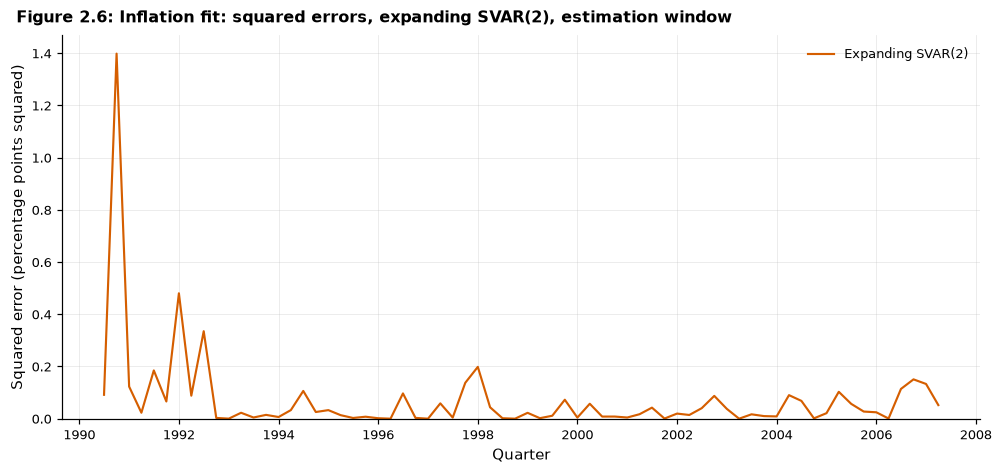

In [26]:
fig = plots.squared_errors({"Expanding SVAR(2)": squared(exp_is, "pi")})
nb.figure(
    fig,
    "expanding_se_inflation",
    "Inflation fit: squared errors, expanding SVAR(2), estimation window",
)

## Out-of-sample evaluation

We next evaluate the expanding-window SVAR(2) over the post-training period beginning in 2007Q3. For each
quarter $t$, coefficients are re-estimated using all data available through quarter $t-1$, and
one-step-ahead fitted values are constructed using realized lagged regressors.

This recursive re-estimation scheme corresponds to expanding-window forecast evaluation, as opposed to
rolling-window evaluation (Giacomini & White, 2006).

Relative to the fixed-parameter baseline, the expanding-window specification allows coefficients to update
as new information arrives. Relative to the rolling-window specification, it avoids discarding earlier
observations and therefore typically produces smoother, less noisy coefficient estimates.

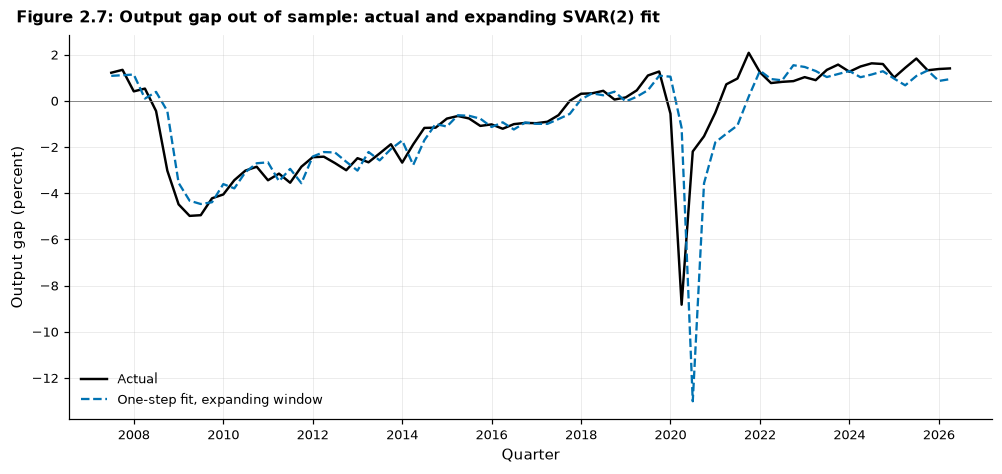

In [27]:
fig = plots.actual_vs_fit(exp_oos, "y", {"One-step fit, expanding window": "y_hat"})
nb.figure(
    fig,
    "expanding_oos_output_gap",
    "Output gap out of sample: actual and expanding SVAR(2) fit",
)

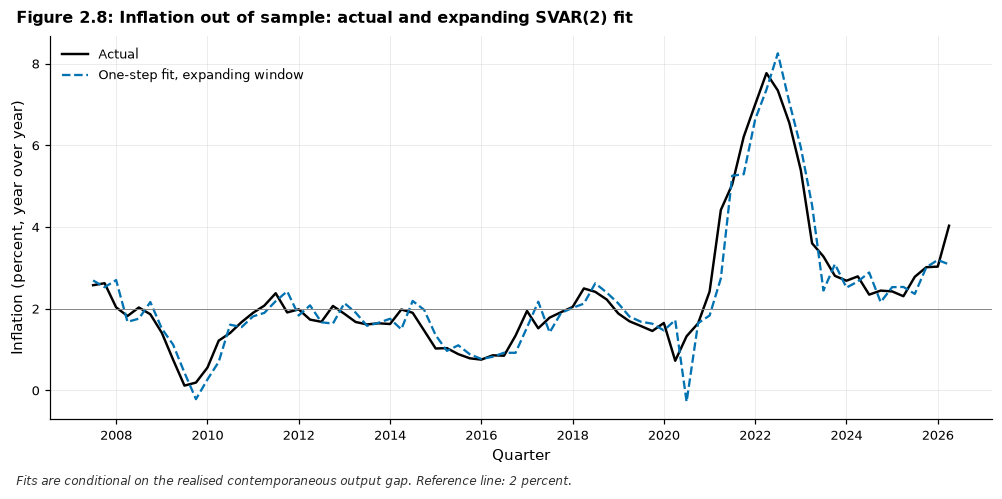

In [28]:
fig = plots.actual_vs_fit(exp_oos, "pi", {"One-step fit, expanding window": "pi_hat"})
nb.figure(
    fig,
    "expanding_oos_inflation",
    "Inflation out of sample: actual and expanding SVAR(2) fit",
    note=(
        "Fits are conditional on the realised contemporaneous output gap. Reference line: 2"
        " percent."
    ),
)

# Formal comparison of the re-estimation schemes (`cultivars.forecast`)

The paper's comparison of the re-estimation schemes is descriptive (MSE by eye). `cultivars.forecast`
turns the same exercise into a formal out-of-sample evaluation:

- `Backtest` re-runs the rolling ($W = 40$) and expanding schemes as rolling-origin forecasting exercises
  on the **unconditional** reduced-form VAR, re-estimated at every origin from 2007Q3, and records
  forecasts and outcomes origin by origin so that every downstream test reads aligned series.
- `ForecastComparison` tests the loss differential with Diebold–Mariano (1995), its
  Harvey–Leybourne–Newbold (1997) small-sample correction (the one to read on a window this short) and the
  Giacomini–White (2006) conditional test.

For the output gap, which is ordered first, the unconditional one-step forecast coincides with the
conditional fitted value used above, so the backtest RMSE must reproduce the loop's number exactly; for
inflation the backtest forecast is unconditional and therefore differs from the conditional fit by the
term $a^\pi_{y,0}(y_t - \hat y_t)$.

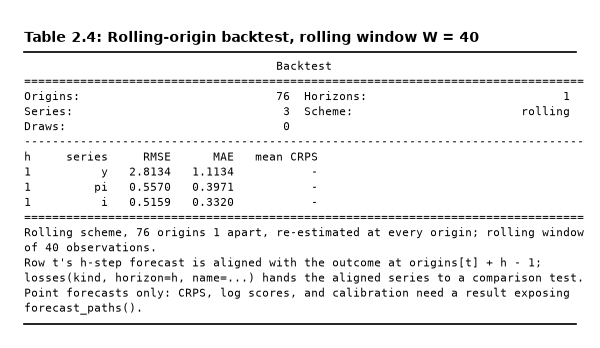

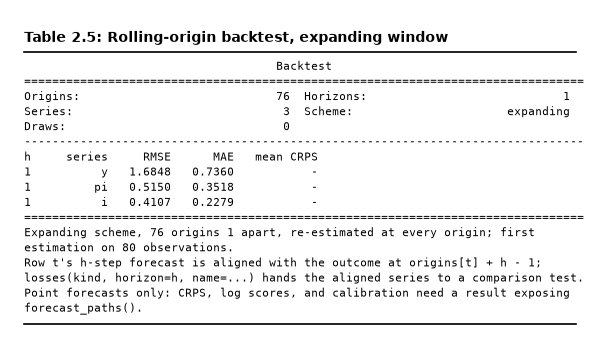

In [29]:
start_index = df_all.index.get_loc(pd.Period(cfg.oos_start, "Q"))


def fit_var(sample: np.ndarray):
    return VAR(sample, order=2, trend="c", names=NAMES).fit()


data = df_all[NAMES].to_numpy()
bt_rolling = Backtest(
    data, fit_var, horizons=1, start=start_index, scheme="rolling", window=W, names=NAMES
).run()
bt_expanding = Backtest(
    data, fit_var, horizons=1, start=start_index, scheme="expanding", names=NAMES
).run()
nb.listing(
    str(bt_rolling.summary()),
    "backtest_rolling",
    f"Rolling-origin backtest, rolling window W = {W}",
)
nb.listing(
    str(bt_expanding.summary()),
    "backtest_expanding",
    "Rolling-origin backtest, expanding window",
)

loop_rmse = {
    "rolling": lin.error_metrics(roll_oos)["RMSE y"],
    "expanding": lin.error_metrics(exp_oos)["RMSE y"],
}
backtest_rmse = {
    "rolling": float(bt_rolling.rmse[0, 0]),
    "expanding": float(bt_expanding.rmse[0, 0]),
}
for scheme in ("rolling", "expanding"):
    assert np.isclose(
        loop_rmse[scheme], backtest_rmse[scheme]
    ), f"{scheme}: loop and backtest disagree"

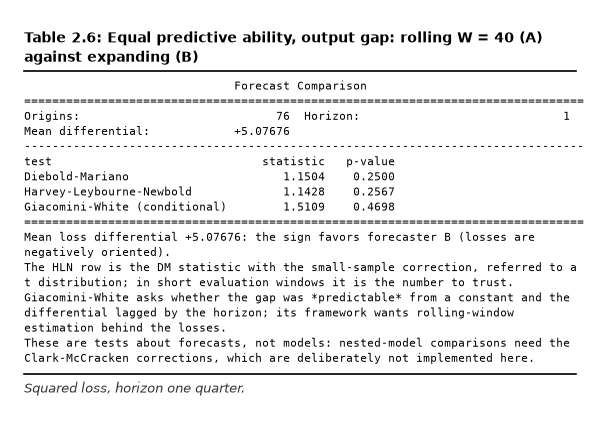

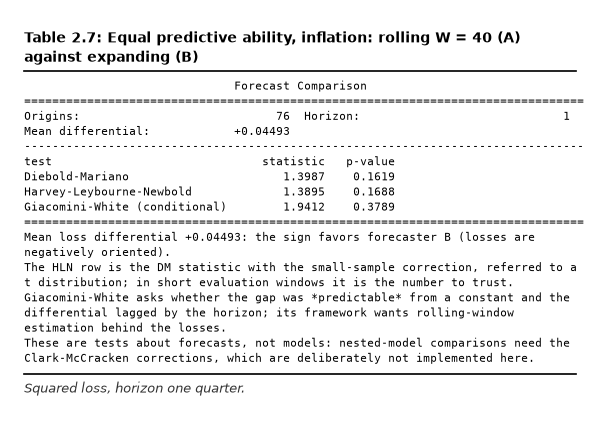

In [30]:
for name in NAMES[:2]:
    comparison = ForecastComparison(
        bt_rolling.losses("squared", horizon=1, name=name),
        bt_expanding.losses("squared", horizon=1, name=name),
    ).compute(horizon=1)
    nb.listing(
        str(comparison.summary()),
        f"forecast_comparison_{name}",
        f"Equal predictive ability, {'output gap' if name == 'y' else 'inflation'}: "
        f"rolling W = {W} (A) against expanding (B)",
        note="Squared loss, horizon one quarter.",
    )

## Model confidence set and forecast efficiency

Two further `cultivars` tools complete the comparison on the conditional one-step fits used throughout the
notebook, aligned origin by origin over 2007Q3 onward:

- `model_confidence_set` (Hansen, Lunde & Nason, 2011) asks which of the four real-time environments --
  fixed restricted, fixed unrestricted, rolling and expanding -- cannot be separated from the best at the
  90% level. It replaces a sequence of pairwise tests with one statement about the set of adequate
  models.
- `mincer_zarnowitz` (Mincer & Zarnowitz, 1969) regresses the outcome on each forecast and tests
  $(a, b) = (0, 1)$: an intercept away from zero is bias, a slope below one says the forecast overreacts
  and would gain from shrinkage toward its mean.

The smoothed TVP fit of the final section is not a real-time forecast and is deliberately left out of the
set.

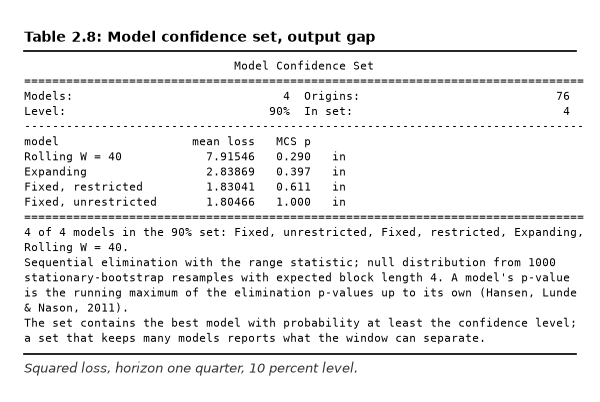

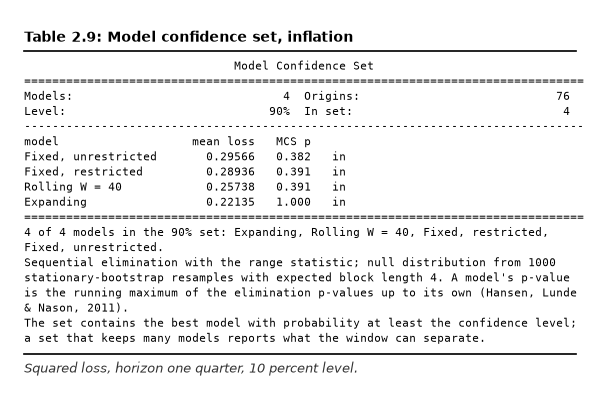

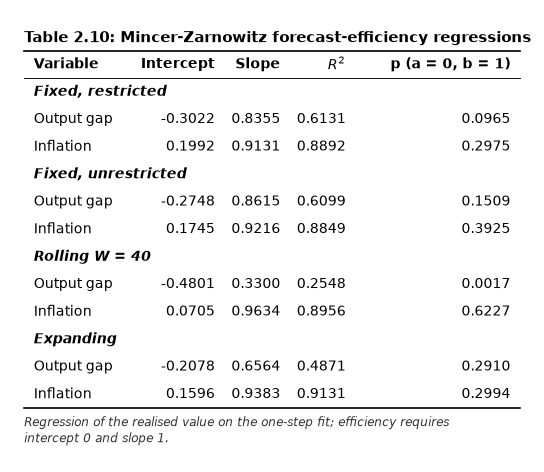

In [31]:
forecasters = {
    "Fixed, restricted": oos_fixed[["y", "pi", "y_hat", "pi_hat"]],
    "Fixed, unrestricted": (
        oos_fixed[["y", "pi", "y_hat_unres", "pi_hat_unres"]].rename(
            columns={"y_hat_unres": "y_hat", "pi_hat_unres": "pi_hat"}
        )
    ),
    f"Rolling W = {W}": roll_oos,
    "Expanding": exp_oos,
}
for frame in forecasters.values():
    assert frame.index.equals(oos_fixed.index), "forecasters must be aligned origin by origin"

for column in ("y", "pi"):
    losses = np.column_stack([squared(f, column).to_numpy() for f in forecasters.values()])
    mcs = model_confidence_set(losses, names=list(forecasters), alpha=0.10, seed=123)
    nb.listing(
        str(mcs.summary()),
        f"model_confidence_set_{column}",
        f"Model confidence set, {'output gap' if column == 'y' else 'inflation'}",
        note="Squared loss, horizon one quarter, 10 percent level.",
    )

rows = {}
for label, f in forecasters.items():
    for column, shown in (("y", "Output gap"), ("pi", "Inflation")):
        mz = mincer_zarnowitz(f[column].to_numpy(), f[f"{column}_hat"].to_numpy(), horizon=1)
        rows[(label, shown)] = {
            "Intercept": mz.intercept,
            "Slope": mz.slope,
            r"$R^2$": mz.r_squared,
            "p (a = 0, b = 1)": mz.pvalue,
        }
mz_table = pd.DataFrame.from_dict(rows, orient="index")
mz_table.index = pd.MultiIndex.from_tuples(mz_table.index, names=["Forecaster", "Variable"])
nb.table(
    mz_table,
    "mincer_zarnowitz",
    "Mincer-Zarnowitz forecast-efficiency regressions",
    float_format="{:.4f}",
    note=(
        "Regression of the realised value on the one-step fit; efficiency requires intercept 0"
        " and slope 1."
    ),
)

# References (APA)

## Software

1. Sunder, N. (2026). cultivars: Research-grade time series econometrics for Python (v1.0.0a1). https://pypi.org/project/cultivars/
2. Sunder, N. (2025). fedfred: A Python client for the Federal Reserve Economic Database (FRED) API (v3.0.0). Zenodo. https://doi.org/10.5281/zenodo.17635942
3. The pandas development team. (2026). pandas-dev/pandas: Pandas. Zenodo. https://doi.org/10.5281/zenodo.18675244
4. Harris, C. R., Millman, K. J., van der Walt, S. J., Gommers, R., Virtanen, P., Cournapeau, D., Wieser, E., Taylor, J., Berg, S., Smith, N. J., Kern, R., Picus, M., Hoyer, S., van Kerkwijk, M. H., Brett, M., Haldane, A., Fernández del Río, J., Wiebe, M., Peterson, P., Gérard-Marchant, P., Sheppard, K., Reddy, T., Weckesser, W., Abbasi, H., Gohlke, C., & Oliphant, T. E. (2020). Array programming with NumPy. *Nature*, 585(7825), 357–362. https://doi.org/10.1038/s41586-020-2649-2
5. Virtanen, P., Gommers, R., Oliphant, T. E., Haberland, M., Reddy, T., Cournapeau, D., Burovski, E., Peterson, P., Weckesser, W., Bright, J., van der Walt, S. J., Brett, M., Wilson, J., Millman, K. J., Mayorov, N., Nelson, A. R. J., Jones, E., Kern, R., Larson, E., … SciPy 1.0 Contributors. (2020). SciPy 1.0: Fundamental algorithms for scientific computing in Python. *Nature Methods*, 17, 261–272. https://doi.org/10.1038/s41592-019-0686-2
6. The Matplotlib Development Team. (2025). Matplotlib: Visualization with Python. Zenodo. https://doi.org/10.5281/zenodo.17595503
7. Seabold, S., & Perktold, J. (2010). statsmodels: Econometric and statistical modeling with Python. In *Proceedings of the 9th Python in Science Conference* (pp. 92–96). https://doi.org/10.25080/Majora-92bf1922-011
8. Kluyver, T., Ragan-Kelley, B., Pérez, F., Granger, B., Bussonnier, M., Frederic, J., Kelley, K., Hamrick, J., Grout, J., Corlay, S., Ivanov, P., Avila, D., Abdalla, S., Willing, C., & Jupyter Development Team. (2016). Jupyter Notebooks – a publishing format for reproducible computational workflows. In *Positioning and Power in Academic Publishing: Players, Agents and Agendas* (pp. 87–90). IOS Press. https://doi.org/10.3233/978-1-61499-649-1-87
9. Python Software Foundation. (2025). Python (Version 3.13) [Computer software]. https://www.python.org/

## Papers & Books

1. Hinterlang, N., & Tänzer, A. (2021). Optimal monetary policy using reinforcement learning. *SSRN*. https://doi.org/10.2139/ssrn.4013384
2. Sims, C. A. (1980). Macroeconomics and reality. *Econometrica*, 48(1), 1–48. https://doi.org/10.2307/1912017
3. Lütkepohl, H. (2005). *New introduction to multiple time series analysis*. Springer. https://doi.org/10.1007/3-540-27752-8
4. Clements, M. P., & Hendry, D. F. (1998). *Forecasting economic time series*. Cambridge University Press. https://doi.org/10.1017/CBO9780511599286
5. Stock, J. H., & Watson, M. W. (2007). Why has U.S. inflation become harder to forecast? *Journal of Money, Credit and Banking*, 39(s1), 3–33. https://doi.org/10.1111/j.1538-4616.2007.00014.x
6. Cogley, T., & Sargent, T. J. (2005). Drifts and volatilities: Monetary policies and outcomes in the post WWII US. *Review of Economic Dynamics*, 8(2), 262–302. https://doi.org/10.1016/j.red.2004.10.009
7. Primiceri, G. E. (2005). Time varying structural vector autoregressions and monetary policy. *Review of Economic Studies*, 72(3), 821–852. https://doi.org/10.1111/j.1467-937X.2005.00353.x
8. Hamilton, J. D. (1994). *Time series analysis*. Princeton University Press.
9. Giacomini, R., & White, H. (2006). Tests of conditional predictive ability. *Econometrica*, 74(6), 1545–1578. https://doi.org/10.1111/j.1468-0262.2006.00718.x
10. Carter, C. K., & Kohn, R. (1994). On Gibbs sampling for state space models. *Biometrika*, 81(3), 541–553. https://doi.org/10.1093/biomet/81.3.541
11. Kim, S., Shephard, N., & Chib, S. (1998). Stochastic volatility: Likelihood inference and comparison with ARCH models. *Review of Economic Studies*, 65(3), 361–393. https://doi.org/10.1111/1467-937X.00050
12. Kim, C.-J., & Nelson, C. R. (1999). *State-space models with regime switching: Classical and Gibbs-sampling approaches with applications*. MIT Press.
13. Diebold, F. X., & Mariano, R. S. (1995). Comparing predictive accuracy. *Journal of Business & Economic Statistics*, 13(3), 253–263. https://doi.org/10.1080/07350015.1995.10524599
14. Harvey, D., Leybourne, S., & Newbold, P. (1997). Testing the equality of prediction mean squared errors. *International Journal of Forecasting*, 13(2), 281–291. https://doi.org/10.1016/S0169-2070(96)00719-4
15. Hansen, P. R., Lunde, A., & Nason, J. M. (2011). The model confidence set. *Econometrica*, 79(2), 453–497. https://doi.org/10.3982/ECTA5771
16. Mincer, J., & Zarnowitz, V. (1969). The evaluation of economic forecasts. In J. Mincer (Ed.), *Economic forecasts and expectations: Analysis of forecasting behavior and performance* (pp. 3–46). NBER.
17. Waggoner, D. F., & Zha, T. (1999). Conditional forecasts in dynamic multivariate models. *Review of Economics and Statistics*, 81(4), 639–651. https://doi.org/10.1162/003465399558508
18. Federal Reserve Bank of St. Louis. (n.d.). *Federal Reserve Economic Data (FRED)*. https://fred.stlouisfed.org/

# Export

The last cell converts this notebook to PDF in the shared `documents/` directory. A kernel can only
convert the copy saved on disk, so the cell waits briefly for the editor to save; if the file is still
behind, it writes nothing and asks you to save and run it again.

In [32]:
nb.export_pdf()

/var/folders/cj/p5jdwnb923752l7zjc_69j5w0000gn/T/ipykernel_87782/281924391.py:1: UserWarning: 02_linear_rolling_expanding.ipynb on disk does not yet contain this run's outputs, so no PDF was written. Save the notebook and run this cell again.
  nb.export_pdf()
